# Part B: LeNet-5 on MNIST with Hyperparameter Tuning

**Aim:** Implement the classic LeNet-5 architecture on MNIST, measure its layer-wise complexity, and use a bounded KerasTuner search to select a stronger configuration.

Each section uses short **what / why** explanations.

## 1. Setup and leakage-safe preprocessing

**What:** Load MNIST, split training data into train/validation, and pad images to 32×32.
**Why:** The 32×32 input matches classic LeNet-5 while keeping the official test set untouched.

In [1]:
import os
import random
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras_tuner as kt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print(f"Python: {sys.version.split()[0]}; TensorFlow: {tf.__version__}; KerasTuner: {kt.__version__}")

Python: 3.14.6; TensorFlow: 2.22.0-rc0; KerasTuner: 1.4.8


In [2]:
(x_train_raw, y_train_raw), (x_test_raw, y_test) = tf.keras.datasets.mnist.load_data()
x_train_raw, x_val_raw, y_train, y_val = train_test_split(x_train_raw, y_train_raw, test_size=0.10, stratify=y_train_raw, random_state=SEED)

def prepare_mnist(images):
    images = images.astype("float32") / 255.0
    images = np.pad(images, ((0, 0), (2, 2), (2, 2)), mode="constant")
    return images[..., np.newaxis]

x_train, x_val, x_test = prepare_mnist(x_train_raw), prepare_mnist(x_val_raw), prepare_mnist(x_test_raw)
y_train, y_val, y_test = y_train.astype("int64"), y_val.astype("int64"), y_test.astype("int64")
for name, images, labels in [("train", x_train, y_train), ("validation", x_val, y_val), ("test", x_test, y_test)]:
    assert images.shape[1:] == (32, 32, 1) and images.dtype == np.float32
    assert np.isfinite(images).all() and 0 <= images.min() <= images.max() <= 1
    assert labels.ndim == 1 and labels.min() >= 0 and labels.max() <= 9
    print(f"{name}: images={images.shape}, labels={labels.shape}")
print("The original 28×28 images are zero-padded to 32×32 for classic LeNet-5.")

train: images=(54000, 32, 32, 1), labels=(54000,)
validation: images=(6000, 32, 32, 1), labels=(6000,)
test: images=(10000, 32, 32, 1), labels=(10000,)
The original 28×28 images are zero-padded to 32×32 for classic LeNet-5.


,digit,training_count
0,0,5331
1,1,6068
2,2,5362
3,3,5518
4,4,5258
5,5,4879
6,6,5326
7,7,5638
8,8,5266
9,9,5354


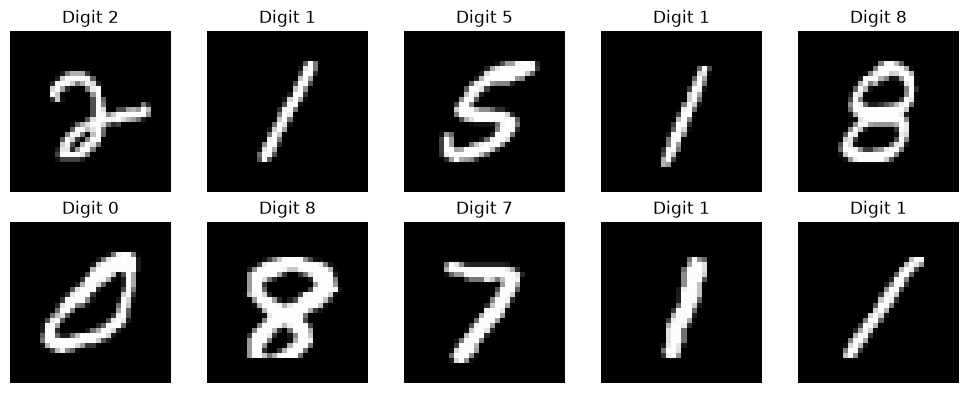

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, image, label in zip(axes.ravel(), x_train[:10], y_train[:10]):
    ax.imshow(image[..., 0], cmap="gray"); ax.set_title(f"Digit {label}"); ax.axis("off")
plt.tight_layout()
class_counts = np.bincount(y_train, minlength=10)
display_table = pd.DataFrame({"digit": np.arange(10), "training_count": class_counts})
display(display_table)

## 2. Classic LeNet-5 baseline

**What:** Build LeNet-5 with `tanh`, average pooling, and the historical 6→16→120 channel progression.
**Why:** These choices reproduce the classic architecture rather than silently modernizing it to ReLU/max pooling.

In [4]:
def build_baseline_lenet():
    model = tf.keras.Sequential([
        tf.keras.layers.Input((32, 32, 1), name="input"),
        tf.keras.layers.Conv2D(6, 5, activation="tanh", name="conv1"),
        tf.keras.layers.AveragePooling2D(2, name="pool1"),
        tf.keras.layers.Conv2D(16, 5, activation="tanh", name="conv2"),
        tf.keras.layers.AveragePooling2D(2, name="pool2"),
        tf.keras.layers.Conv2D(120, 5, activation="tanh", name="conv3"),
        tf.keras.layers.Flatten(name="flatten"),
        tf.keras.layers.Dense(84, activation="tanh", name="dense1"),
        tf.keras.layers.Dense(10, activation="softmax", name="classifier"),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

baseline_model = build_baseline_lenet()
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (AveragePooling2D)        │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (AveragePooling2D)        │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 1, 1, 120)      │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
def complexity_rows(model, input_shape):
    tensor = tf.zeros((1, *input_shape), dtype=tf.float32); rows=[]
    for layer in model.layers:
        input_tensor=tensor; tensor=layer(tensor, training=False)
        output_shape=tuple(int(d) for d in tensor.shape[1:]); macs=0
        if isinstance(layer, tf.keras.layers.Conv2D):
            kh, kw=layer.kernel_size; macs=int(np.prod(output_shape)*kh*kw*int(input_tensor.shape[-1]))
        elif isinstance(layer, tf.keras.layers.Dense):
            macs=int(input_tensor.shape[-1]*layer.units)
        rows.append({"layer":layer.name,"output_shape":output_shape,"parameters":int(layer.count_params()),"activations":int(np.prod(output_shape)),"approx_MACs":macs})
    return pd.DataFrame(rows)

baseline_complexity=complexity_rows(baseline_model,(32,32,1))
display(baseline_complexity)
print("Baseline parameters:", baseline_model.count_params(), "Approximate MACs:", baseline_complexity.approx_MACs.sum())
assert baseline_complexity.parameters.sum()==baseline_model.count_params()
assert tuple(baseline_complexity.iloc[-1].output_shape)==(10,)

,layer,output_shape,parameters,activations,approx_MACs
0,conv1,"(28, 28, 6)",156,4704,117600
1,pool1,"(14, 14, 6)",0,1176,0
2,conv2,"(10, 10, 16)",2416,1600,240000
3,pool2,"(5, 5, 16)",0,400,0
4,conv3,"(1, 1, 120)",48120,120,48000
5,flatten,"(120,)",0,120,0
6,dense1,"(84,)",10164,84,10080
7,classifier,"(10,)",850,10,840


Baseline parameters: 61706 Approximate MACs: 416520


Epoch 1/8


422/422 - 4s - 10ms/step - accuracy: 0.8962 - loss: 0.3557 - val_accuracy: 0.9455 - val_loss: 0.1794


Epoch 2/8


422/422 - 4s - 8ms/step - accuracy: 0.9609 - loss: 0.1302 - val_accuracy: 0.9652 - val_loss: 0.1108


Epoch 3/8


...

422/422 - 4s - 9ms/step - accuracy: 0.9881 - loss: 0.0393 - val_accuracy: 0.9755 - val_loss: 0.0785


Epoch 7/8


422/422 - 4s - 9ms/step - accuracy: 0.9908 - loss: 0.0316 - val_accuracy: 0.9770 - val_loss: 0.0782


Epoch 8/8


422/422 - 4s - 9ms/step - accuracy: 0.9929 - loss: 0.0259 - val_accuracy: 0.9793 - val_loss: 0.0729


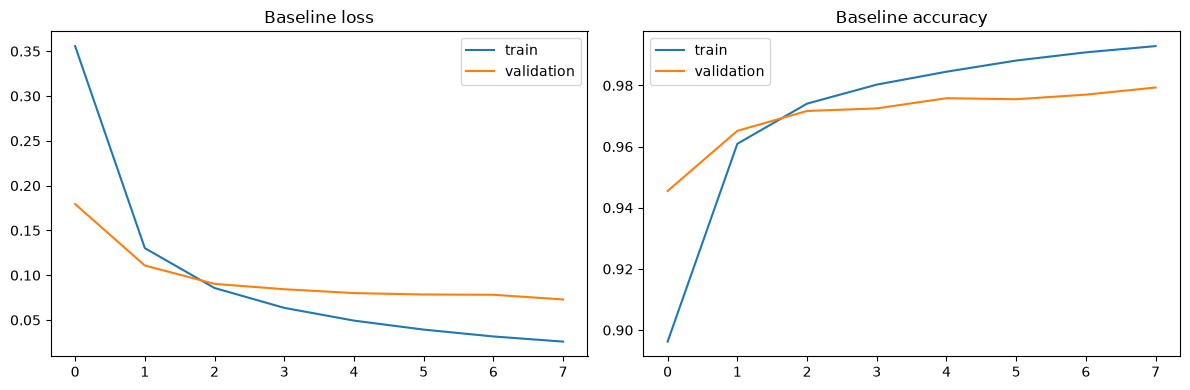

In [6]:
baseline_stop=tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=2,restore_best_weights=True)
baseline_history=baseline_model.fit(x_train,y_train,validation_data=(x_val,y_val),epochs=8,batch_size=128,callbacks=[baseline_stop],verbose=2)
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].plot(baseline_history.history["loss"],label="train"); axes[0].plot(baseline_history.history["val_loss"],label="validation"); axes[0].set_title("Baseline loss"); axes[0].legend()
axes[1].plot(baseline_history.history["accuracy"],label="train"); axes[1].plot(baseline_history.history["val_accuracy"],label="validation"); axes[1].set_title("Baseline accuracy"); axes[1].legend(); plt.tight_layout()

## 3. Bounded KerasTuner RandomSearch

**What:** Search a small, reproducible hyperparameter space using validation accuracy.
**Why:** Validation data selects configurations; the test set remains reserved for the final comparison.

In [7]:
def build_tunable_lenet(hp):
    filters1=hp.Choice("filters1",[6,12]); filters2=hp.Choice("filters2",[16,32])
    dense_units=hp.Choice("dense_units",[84,120]); dropout_rate=hp.Choice("dropout_rate",[0.0,0.2,0.4])
    learning_rate=hp.Choice("learning_rate",[1e-3,3e-4]); batch_size=hp.Choice("batch_size",[64,128])
    model=tf.keras.Sequential([
        tf.keras.layers.Input((32,32,1),name="input"),
        tf.keras.layers.Conv2D(filters1,5,activation="tanh",name="conv1"),
        tf.keras.layers.AveragePooling2D(2,name="pool1"),
        tf.keras.layers.Conv2D(filters2,5,activation="tanh",name="conv2"),
        tf.keras.layers.AveragePooling2D(2,name="pool2"),
        tf.keras.layers.Conv2D(120,5,activation="tanh",name="conv3"),
        tf.keras.layers.Flatten(name="flatten"),
        tf.keras.layers.Dense(dense_units,activation="tanh",name="dense1"),
        tf.keras.layers.Dropout(dropout_rate,name="dropout"),
        tf.keras.layers.Dense(10,activation="softmax",name="classifier"),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate),loss="sparse_categorical_crossentropy",metrics=["accuracy"])
    return model

class BatchSizeTuner(kt.RandomSearch):
    def run_trial(self, trial, *args, **kwargs):
        kwargs["batch_size"] = trial.hyperparameters.get("batch_size")
        return super().run_trial(trial, *args, **kwargs)

tuner=BatchSizeTuner(build_tunable_lenet,objective="val_accuracy",max_trials=8,seed=SEED,directory="/tmp/keras_tuner_part_b",project_name="lenet5_mnist",overwrite=True)
tuner.search(x_train,y_train,epochs=8,validation_data=(x_val,y_val),callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=2,restore_best_weights=True)],verbose=0)
tuner.results_summary(num_trials=8)

Results summary
Results in /tmp/keras_tuner_part_b/lenet5_mnist
Showing 8 best trials
Objective(name="val_accuracy", direction="max")

Trial 3 summary
Hyperparameters:
filters1: 6
filters2: 16
dense_units: 120
dropout_rate: 0.2
learning_rate: 0.001
batch_size: 64
Score: 0.9825000166893005

Trial 6 summary
Hyperparameters:
filters1: 12
filters2: 16
dense_units: 84
dropout_rate: 0.2
learning_rate: 0.001
batch_size: 64
Score: 0.9823333621025085

Trial 5 summary
Hyperparameters:
filters1: 6
filters2: 16
dense_units: 120
dropout_rate: 0.2
learning_rate: 0.001
batch_size: 128
Score: 0.9804999828338623

Trial 4 summary
Hyperparameters:
filters1: 6
filters2: 16
dense_units: 120
dropout_rate: 0.4
learning_rate: 0.0003
batch_size: 64
Score: 0.9803333282470703

Trial 2 summary
Hyperparameters:
filters1: 12
filters2: 16
dense_units: 120
dropout_rate: 0.0
learning_rate: 0.0003
batch_size: 64
Score: 0.9798333048820496

Trial 0 summary
Hyperparameters:
filters1: 12
filters2: 16
dense_units: 84
dropou

In [8]:
trial_rows=[]
for trial in tuner.oracle.trials.values():
    row={"trial_id":trial.trial_id,"val_accuracy":trial.score,"status":trial.status}; row.update(trial.hyperparameters.values); trial_rows.append(row)
best_trial_summary=pd.DataFrame(trial_rows).sort_values("val_accuracy",ascending=False)
display(best_trial_summary)
best_hyperparameters=tuner.get_best_hyperparameters(1)[0]
print("Best hyperparameters:", best_hyperparameters.values)

,trial_id,val_accuracy,status,filters1,filters2,dense_units,dropout_rate,learning_rate,batch_size
3,3,0.982500,COMPLETED,6,16,120,0.2,0.0010,64
6,6,0.982333,COMPLETED,12,16,84,0.2,0.0010,64
5,5,0.980500,COMPLETED,6,16,120,0.2,0.0010,128
4,4,0.980333,COMPLETED,6,16,120,0.4,0.0003,64
2,2,0.979833,COMPLETED,12,16,120,0.0,0.0003,64
0,0,0.978500,COMPLETED,12,16,84,0.0,0.0003,64
7,7,0.977333,COMPLETED,12,16,120,0.0,0.0010,64
1,1,0.976000,COMPLETED,12,16,84,0.0,0.0003,128


Best hyperparameters: {'filters1': 6, 'filters2': 16, 'dense_units': 120, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 64}


## 4. Clean retraining and final comparison

**What:** Rebuild the selected configuration from fresh weights and evaluate it once on the untouched test set.
**Why:** A tuner trial is for selection; clean retraining avoids reporting a partially trained search state.

In [9]:
tuned_model=build_tunable_lenet(best_hyperparameters)
tuned_stop=tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=2,restore_best_weights=True)
tuned_history=tuned_model.fit(x_train,y_train,validation_data=(x_val,y_val),epochs=10,batch_size=best_hyperparameters.get("batch_size"),callbacks=[tuned_stop],verbose=2)


Epoch 1/10


844/844 - 6s - 7ms/step - accuracy: 0.9045 - loss: 0.3144 - val_accuracy: 0.9528 - val_loss: 0.1555


Epoch 2/10


844/844 - 5s - 6ms/step - accuracy: 0.9635 - loss: 0.1195 - val_accuracy: 0.9687 - val_loss: 0.1017


Epoch 3/10


...

844/844 - 5s - 6ms/step - accuracy: 0.9856 - loss: 0.0475 - val_accuracy: 0.9815 - val_loss: 0.0618


Epoch 6/10


844/844 - 5s - 6ms/step - accuracy: 0.9875 - loss: 0.0396 - val_accuracy: 0.9798 - val_loss: 0.0681


Epoch 7/10


844/844 - 5s - 6ms/step - accuracy: 0.9898 - loss: 0.0331 - val_accuracy: 0.9828 - val_loss: 0.0623


,model,test_accuracy,parameters,val_accuracy
0,baseline,0.9818,61706,0.979333
1,tuned,0.9860,66422,0.982833


,precision,recall,f1-score,support
0,0.992,0.989,0.990,980.000
1,0.994,0.992,0.993,1135.000
2,0.975,0.994,0.985,1032.000
3,0.986,0.984,0.985,1010.000
4,0.977,0.993,0.985,982.000
5,0.984,0.988,0.986,892.000
6,0.985,0.986,0.986,958.000
7,0.987,0.981,0.984,1028.000
8,0.987,0.990,0.988,974.000
9,0.992,0.963,0.977,1009.000


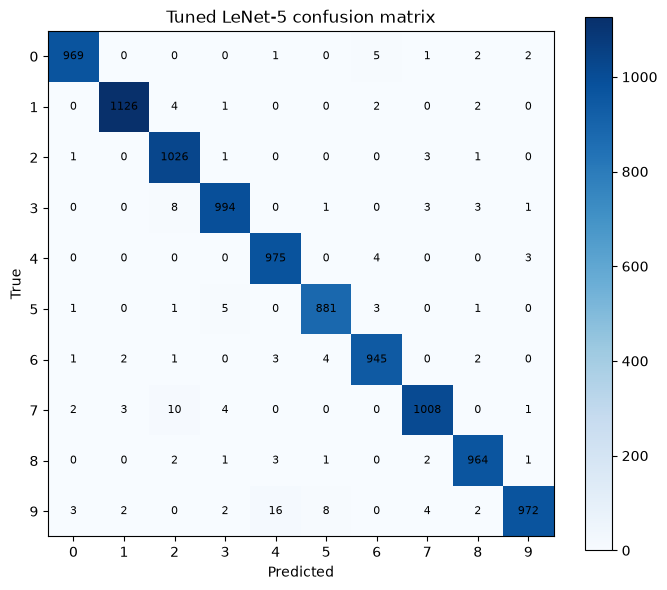

In [10]:
tuned_loss,tuned_accuracy=tuned_model.evaluate(x_test,y_test,verbose=0)
y_pred=tuned_model.predict(x_test,verbose=0).argmax(axis=1)
report=classification_report(y_test,y_pred,labels=np.arange(10),target_names=[str(i) for i in range(10)],output_dict=True,zero_division=0)
report_df=pd.DataFrame(report).T
tuned_metrics={"accuracy":float(tuned_accuracy),"loss":float(tuned_loss),"macro_f1":float(report["macro avg"]["f1-score"]),"weighted_f1":float(report["weighted avg"]["f1-score"])}
cm=confusion_matrix(y_test,y_pred,labels=np.arange(10))
assert cm.shape==(10,10) and len(y_pred)==len(y_test)
comparison=pd.DataFrame([
 {"model":"baseline","test_accuracy":float(baseline_model.evaluate(x_test,y_test,verbose=0)[1]),"parameters":baseline_model.count_params(),"val_accuracy":max(baseline_history.history["val_accuracy"])},
 {"model":"tuned","test_accuracy":tuned_metrics["accuracy"],"parameters":tuned_model.count_params(),"val_accuracy":max(tuned_history.history["val_accuracy"])}
])
display(comparison); display(report_df.round(3))
fig,ax=plt.subplots(figsize=(7,6)); image=ax.imshow(cm,cmap="Blues"); fig.colorbar(image,ax=ax); ax.set(xlabel="Predicted",ylabel="True",title="Tuned LeNet-5 confusion matrix"); ax.set_xticks(range(10)); ax.set_yticks(range(10))
for r in range(10):
    for c in range(10): ax.text(c,r,cm[r,c],ha="center",va="center",fontsize=8)
plt.tight_layout()

## 5. Tuning safeguards

| Mistake | Fix in this notebook |
|---|---|
| Tune on test data | The tuner sees only train and validation splits. |
| Unbounded search | RandomSearch is limited to eight trials and short epochs. |
| Select by training accuracy | The objective is `val_accuracy`. |
| Reuse a partial trial | The best hyperparameters are rebuilt and retrained from fresh weights. |
| Ignore cost | The comparison includes parameters and validation/test performance. |

**References:** [KerasTuner getting started](https://keras.io/keras_tuner/getting_started/) and [TensorFlow KerasTuner guide](https://www.tensorflow.org/tutorials/keras/keras_tuner).